# Freight rate prediction

Predict posted freight rates in dollars per load. This notebook contains the complete
workflow, from the four supplied CSVs to the two submission files, the unchanged
company scorer's chart, and a short PDF report. Run every cell in order from the
repository root, using the environment in `requirements.txt` (Python 3.11.5 was used).
Training takes a few minutes on CPU, models stay in memory.

We compare models on July and August, keep the existing choices fixed, evaluate
September and October, and only then refit on all labeled data. The held-out
scores belong to the January–August fits, not the final submission models.

## 1. Imports and data loading

The development file contains January–October labels, the validation file contains
November–December inputs without labels. December is a separate fixed scenario with
only six available predictors. The supplied files are read without editing them.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

# Resolve all file paths from the repository root.
ROOT = Path.cwd()
assert (ROOT / "score.py").is_file(), "Run this notebook from the repository root."
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score
from threadpoolctl import threadpool_limits
import pymupdf

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 3)
# Read the original inputs without changing their contents.
data = ROOT / "data"
development = pd.read_csv(data / "train-test.csv", parse_dates=["date"])
validation = pd.read_csv(data / "validation.csv", parse_dates=["date"])
template = pd.read_csv(data / "validation-predictions-template.csv")
december = pd.read_csv(data / "december-chart-inputs.csv")
# Keep the December inputs for comparison before saving predictions.
december_inputs = december.drop(columns="predicted_rate").copy(deep=True)
print(f"Loaded {len(development):,} labeled loads, {len(validation):,} validation loads, "
      f"and {len(december)} December scenarios.")

Loaded 48,000 labeled loads, 12,000 validation loads, and 31 December scenarios.


## 2. Essential checks and useful charts

Check IDs, dates, physical inputs, and labels before fitting. Missing and negative
weights are present, none of these rows is removed. Large target values also remain:
an expensive load is not automatically a bad record. The charts show data coverage
and the strong distance–price relationship with a small expensive tail.

Earlier descriptive exploration included all development labels. September–October
was reserved from model selection, but was not completely unseen by the analyst.

Development: missing weights=300, negative weights=292
Validation: missing weights=165, negative weights=145
December: missing weights=0, negative weights=0


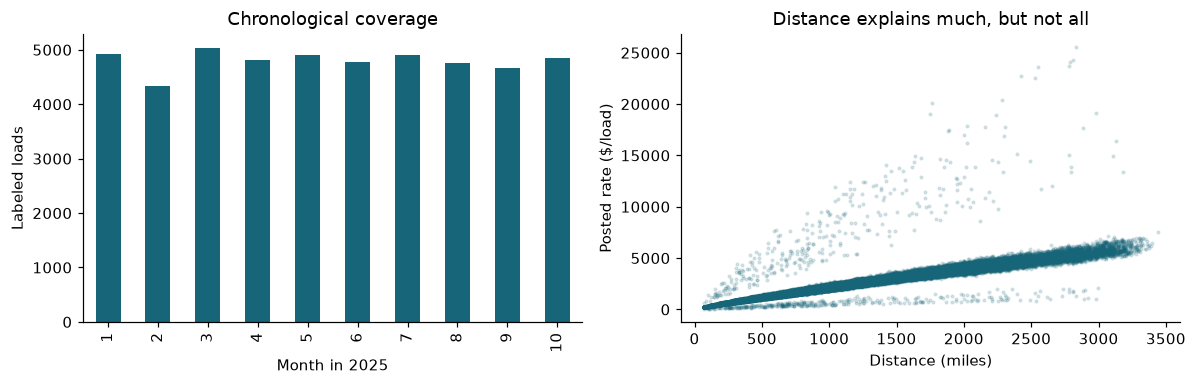

In [2]:
# Confirm that the expected company datasets were loaded.
assert len(development) == 48000 and len(validation) == 12000 and len(december) == 31
# Unique, matching IDs prevent duplicated or missing submission predictions.
for frame in [development, validation, template]:
    assert frame.load_id.notna().all() and frame.load_id.is_unique
assert set(template.load_id) == set(validation.load_id)
assert set(development.load_id).isdisjoint(validation.load_id)
assert list(template.columns) == ["load_id", "predicted_rate"]
# Labels must be valid, and positive distances are needed for rate per mile.
assert np.isfinite(development.posted_rate).all() and development.posted_rate.gt(0).all()
for name, frame in [("Development", development), ("Validation", validation), ("December", december)]:
    assert np.isfinite(frame.distance).all() and frame.distance.gt(0).all()
    assert pd.to_datetime(frame.date).notna().all()
    print(f"{name}: missing weights={frame.weight.isna().sum()}, "
          f"negative weights={frame.weight.lt(0).sum()}")
# Confirm the time coverage used by the chronological evaluation.
assert development.date.min() == pd.Timestamp("2025-01-01")
assert development.date.max() == pd.Timestamp("2025-10-31")
assert validation.date.min() == pd.Timestamp("2025-11-01")
assert validation.date.max() == pd.Timestamp("2025-12-31")
# The December scenario changes only the date across 31 daily rows.
assert pd.to_datetime(december.date).tolist() == list(pd.date_range("2025-12-01", "2025-12-31"))
assert december_inputs.drop(columns="date").nunique().eq(1).all()

# These descriptive charts show monthly coverage and the expensive-load tail.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
development.groupby(development.date.dt.month).size().plot.bar(ax=axes[0], color="#176578")
axes[0].set(xlabel="Month in 2025", ylabel="Labeled loads", title="Chronological coverage")
axes[1].scatter(development.distance, development.posted_rate, s=3, alpha=.15, color="#176578")
axes[1].set(xlabel="Distance (miles)", ylabel="Posted rate ($/load)", title="Distance explains much, but not all")
plt.tight_layout()
plt.show()

## 3. Shared feature preparation and fixed model settings

One function prepares both training and prediction inputs. It creates a directed
route, weekday/year cycles, and elapsed days from January 1. IDs, the target,
`market_index`, and `quote_signal` never enter the features. The signals' definitions,
generation times, and availability at prediction time remain unresolved.

The selected CatBoost models mask negative weights as missing and retain an
`invalid_weight` flag. Native CatBoost missing-value handling and categorical
statistics are learned during training only. No scaling or external imputation is
needed for CatBoost. For an exact reproduction of the existing Ridge benchmark,
Ridge uses the six December inputs and retains raw negative weights, its imputer,
scaler, and encoder are fitted inside a training-only pipeline.

The settings below reproduce the existing selected configurations. They are not
searched or changed in this notebook. The target remains dollars per load, with
MAE loss and the existing $0.01 prediction floor, there is no upper cap.

In [3]:
CATEGORICAL = ["pickup", "delivery", "route", "equipment"]
COORDINATES = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]
# Keep the existing model settings fixed throughout comparison and final training.
CATBOOST_OPTIONS = dict(
    iterations=450, depth=6, learning_rate=.08, loss_function="MAE",
    l2_leaf_reg=5.0, random_seed=2025, thread_count=2, task_type="CPU",
    boosting_type="Plain", max_ctr_complexity=1, one_hot_max_size=10,
    nan_mode="Min", allow_writing_files=False, verbose=False,
)

def prepare_features(frame, coordinates=True, mask_negative=True):
    """Stateless transformations, explicitly select predictors, never labels or IDs."""
    result = pd.DataFrame(index=frame.index)
    for column in ["pickup", "delivery", "equipment"]:
        result[column] = frame[column].fillna("__MISSING__").astype(str)
    # Encode the direction of the route, with a prefix to avoid city-name collisions.
    result["route"] = result.pickup.str.len().astype(str) + ":" + result.pickup + result.delivery
    for column in ["distance", "weight"] + (COORDINATES if coordinates else []):
        result[column] = pd.to_numeric(frame[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
    # Record which weights were negative before treating them as unavailable.
    if mask_negative:
        result["invalid_weight"] = result.weight.lt(0).astype(float)
        result.loc[result.weight.lt(0), "weight"] = np.nan
    dates = pd.to_datetime(frame.date, errors="raise")
    assert dates.notna().all()
    # Cycles keep neighboring weekdays and year-end dates close in feature space.
    result["day_of_week_sin"] = np.sin(2 * np.pi * dates.dt.dayofweek / 7)
    result["day_of_week_cos"] = np.cos(2 * np.pi * dates.dt.dayofweek / 7)
    result["day_of_year_sin"] = np.sin(2 * np.pi * (dates.dt.dayofyear - 1) / 365.25)
    result["day_of_year_cos"] = np.cos(2 * np.pi * (dates.dt.dayofyear - 1) / 365.25)
    result["elapsed_days"] = (dates - pd.Timestamp("2025-01-01")).dt.days.astype(float)
    assert {"load_id", "posted_rate", "market_index", "quote_signal"}.isdisjoint(result.columns)
    return result

def fit_catboost(training, coordinates):
    model = CatBoostRegressor(**CATBOOST_OPTIONS)
    # Only training features and labels enter fit, with no evaluation set or early stopping.
    model.fit(prepare_features(training, coordinates), training.posted_rate, cat_features=CATEGORICAL)
    assert model.tree_count_ == 450
    return model

def metrics(actual, predicted):
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    assert actual.shape == predicted.shape and len(actual) > 0
    assert np.isfinite(actual).all() and np.isfinite(predicted).all()
    # Negative signed error means underprediction, and RMSE emphasizes large misses.
    error = predicted - actual
    return dict(n=len(actual), mae=np.abs(error).mean(), rmse=np.sqrt(np.mean(error ** 2)),
                r2=r2_score(actual, predicted) if len(actual) > 1 else np.nan, bias=error.mean())

print("Validation features:", ", ".join(prepare_features(development.head()).columns))
print("December features:", ", ".join(prepare_features(development.head(), False).columns))

Validation features: pickup, delivery, equipment, route, distance, weight, pickup_lat, pickup_lon, delivery_lat, delivery_lon, invalid_weight, day_of_week_sin, day_of_week_cos, day_of_year_sin, day_of_year_cos, elapsed_days
December features: pickup, delivery, equipment, route, distance, weight, invalid_weight, day_of_week_sin, day_of_week_cos, day_of_year_sin, day_of_year_cos, elapsed_days


## 4. July–August chronological comparison

January–June predicts July (4,912 loads), January–July predicts August (4,759).
Each fit receives only earlier rows. The mileage baseline is the training median
rate per mile times distance. Ridge is a simple linear comparison, the two CatBoost
models allow nonlinear relationships and categorical routes/equipment.

Pooled MAE treats each load equally, rather than averaging the two monthly scores.
The compact table also shows pooled RMSE and R² to expose large errors.

In [4]:
# Each month is evaluated using only the rows dated before that month.
comparison_parts = []
for month, start, end, expected_train, expected_eval in [
    ("July", "2025-07-01", "2025-08-01", 28806, 4912),
    ("August", "2025-08-01", "2025-09-01", 33718, 4759),
]:
    train = development.loc[development.date.lt(start)].copy()
    evaluate = development.loc[development.date.ge(start) & development.date.lt(end)].copy()
    assert len(train) == expected_train and len(evaluate) == expected_eval
    assert train.date.max() < evaluate.date.min()
    assert set(train.load_id).isdisjoint(evaluate.load_id)
    # Estimate a typical price per mile from training data alone.
    predictions = {"Mileage baseline": np.median(train.posted_rate / train.distance) * evaluate.distance.to_numpy()}

    # All learned Ridge preprocessing is inside the fit on this fold's training rows.
    # Retain the original Ridge benchmark weight handling for a comparable result.
    ridge_train = prepare_features(train, coordinates=False, mask_negative=False)
    numeric = [column for column in ridge_train if column not in CATEGORICAL]
    preprocessing = ColumnTransformer([
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]), numeric),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL),
    ], sparse_threshold=1.0)
    ridge = Pipeline([("preprocess", preprocessing),
                      ("model", Ridge(alpha=10.0, solver="lsqr", tol=1e-5, max_iter=2000))])
    with threadpool_limits(limits=2):
        ridge.fit(ridge_train, train.posted_rate)
        predictions["Ridge (December inputs)"] = ridge.predict(
            prepare_features(evaluate, coordinates=False, mask_negative=False))
        # Fit both fixed CatBoost variants on the same training and evaluation rows.
        for name, coordinates in [("Signal-free CatBoost", True), ("December CatBoost", False)]:
            model = fit_catboost(train, coordinates)
            predictions[name] = model.predict(prepare_features(evaluate, coordinates))

    part = evaluate[["load_id", "date", "pickup", "delivery", "equipment", "distance", "weight", "posted_rate"]].copy()
    part["fold"] = month
    part["above_training_P99"] = part.posted_rate.gt(train.posted_rate.quantile(.99))
    for name, predicted in predictions.items():
        assert len(predicted) == len(evaluate) and np.isfinite(predicted).all()
        part[name] = np.maximum(predicted, .01)
    comparison_parts.append(part)
    print(f"Completed {month}: trained on {len(train):,}, evaluated {len(evaluate):,}.")

# Pool the individual predictions so each load has equal weight in the final metrics.
comparison_predictions = pd.concat(comparison_parts, ignore_index=True)
model_names = list(predictions)
comparison_rows = []
for name in model_names:
    for period in ["July", "August", "ALL"]:
        subset = comparison_predictions if period == "ALL" else comparison_predictions.loc[comparison_predictions.fold.eq(period)]
        comparison_rows.append(dict(model=name, period=period, **metrics(subset.posted_rate, subset[name])))
comparison_metrics = pd.DataFrame(comparison_rows)
comparison_table = comparison_metrics.pivot(index="model", columns="period", values="mae")[["July", "August", "ALL"]]
comparison_table.columns = ["July MAE ($)", "August MAE ($)", "Pooled MAE ($)"]
pooled = comparison_metrics.loc[comparison_metrics.period.eq("ALL")].set_index("model")
comparison_table["Pooled RMSE ($)"] = pooled.rmse
comparison_table["Pooled R²"] = pooled.r2
display(comparison_table.reindex(model_names))

Completed July: trained on 28,806, evaluated 4,912.


Completed August: trained on 33,718, evaluated 4,759.


,July MAE ($),August MAE ($),Pooled MAE ($),Pooled RMSE ($),Pooled R²
model,,,,,
Mileage baseline,241.647,260.523,250.936,676.102,0.794
Ridge (December inputs),269.796,152.889,212.267,647.370,0.811
Signal-free CatBoost,154.803,88.927,122.386,622.807,0.825
December CatBoost,157.805,95.949,127.366,623.862,0.825


## 5. Keep the model choices fixed before the holdout

Signal-free CatBoost has pooled July–August MAE **$122.39**, compared with **$250.94**
for mileage and **$212.27** for Ridge. December CatBoost has MAE **$127.37** and can
use the six supplied December predictors. These are the existing selections, there
is no automatic selection or tuning based on September–October.

The earlier focused weight comparison found only $0.38/$0.84 pooled MAE gains from
masking negative weights. This is weak accuracy evidence: only 37 evaluation rows
had negative weights and their signal-free error actually worsened. Masking is
retained because negative physical weights are invalid and the indicator preserves
that fact, rather than because a large performance benefit was established.

The largest July–August errors are high-rate underpredictions. The previous bounded
review found the same 20 worst rows for both selected models across 19 known routes,
with no negative weights, the mileage baseline also missed them. Sparse physical
combinations add uncertainty, but misses also occur on supported routes. MAE loss
favors typical prices when rare costly loads resemble ordinary ones. No implementation
bug or reliable missing predictor was identified, and no rows were deleted. Extreme
rate per mile is a review flag for special services or possible data issues, not
proof of a bad label. The small table below reproduces a few of these examples.

In [5]:
# Carry forward the July-August choices before evaluating the holdout.
selected_validation = "Signal-free CatBoost"
selected_december = "December CatBoost"
# Inspect the largest earlier errors without dropping rows or changing the models.
review = comparison_predictions.copy()
review["signed_error"] = review[selected_validation] - review.posted_rate
review["rate_per_mile"] = review.posted_rate / review.distance
display(review.loc[review.signed_error.abs().nlargest(5).index,
    ["load_id", "fold", "distance", "posted_rate", selected_validation,
     selected_december, "Mileage baseline", "signed_error", "rate_per_mile"]])
print("Fixed selections:", selected_validation, "and", selected_december)

,load_id,fold,distance,posted_rate,Signal-free CatBoost,December CatBoost,Mileage baseline,signed_error,rate_per_mile
8958,TR-037765,August,2810.9,24294.98,5004.123,4995.988,6027.712,-19290.857,8.643
2453,TR-031260,July,1747.7,19042.39,4102.860,4106.983,3734.715,-14939.530,10.896
5777,TR-034584,August,2242.0,18972.15,4234.517,4231.151,4807.759,-14737.633,8.462
6662,TR-035469,August,2305.9,17742.34,4423.781,4332.706,4944.786,-13318.559,7.694
4268,TR-033075,July,1880.0,17333.65,4170.421,4154.624,4017.431,-13163.229,9.220


Fixed selections: Signal-free CatBoost and December CatBoost


## 6. September–October holdout evaluation

Train the fixed models on 38,477 January–August rows and score the identical 9,523
September–October rows. Evaluation labels are used only after fitting, there is no
evaluation set, early stopping, or model change. Signed bias is prediction minus
target, so negative values mean underprediction.

The reduced-feature model's result estimates the cost of using December-available
inputs. It does **not** directly validate December forecasting or the fixed route.

In [6]:
# Separate January-August training from the September-October holdout.
holdout_train = development.loc[development.date.lt("2025-09-01")].copy()
holdout = development.loc[development.date.ge("2025-09-01") & development.date.lt("2025-11-01")].copy()
assert len(holdout_train) == 38477 and len(holdout) == 9523
assert holdout_train.date.max() == pd.Timestamp("2025-08-31")
assert holdout.date.min() == pd.Timestamp("2025-09-01") and holdout.date.max() == pd.Timestamp("2025-10-31")
assert set(holdout_train.load_id).isdisjoint(holdout.load_id)
# Keep one shared set of evaluation rows for every model and the baseline.
holdout_predictions = holdout.copy()
holdout_predictions["Mileage baseline"] = np.maximum(
    np.median(holdout_train.posted_rate / holdout_train.distance) * holdout.distance.to_numpy(), .01)
# Fit the already selected models, without tuning against the holdout.
holdout_models = {}
with threadpool_limits(limits=2):
    for name, coordinates in [(selected_validation, True), (selected_december, False)]:
        holdout_models[name] = fit_catboost(holdout_train, coordinates)
        predicted = holdout_models[name].predict(prepare_features(holdout, coordinates))
        assert len(predicted) == len(holdout) and np.isfinite(predicted).all()
        holdout_predictions[name] = np.maximum(predicted, .01)
        print(f"Evaluated {name} on the same {len(holdout):,} held-out rows.")

# Report each month separately as well as the pooled holdout result.
holdout_rows = []
for name in [selected_validation, selected_december, "Mileage baseline"]:
    for period, month in [("September", 9), ("October", 10), ("ALL", None)]:
        subset = holdout_predictions if month is None else holdout_predictions.loc[holdout_predictions.date.dt.month.eq(month)]
        holdout_rows.append(dict(model=name, period=period, **metrics(subset.posted_rate, subset[name])))
holdout_metrics = pd.DataFrame(holdout_rows)
display(holdout_metrics)

Evaluated Signal-free CatBoost on the same 9,523 held-out rows.


Evaluated December CatBoost on the same 9,523 held-out rows.


,model,period,n,mae,rmse,r2,bias
0,Signal-free CatBoost,September,4670,109.576,618.407,0.835,-74.706
1,Signal-free CatBoost,October,4853,130.108,657.271,0.815,-88.708
2,Signal-free CatBoost,ALL,9523,120.040,638.508,0.825,-81.841
3,December CatBoost,September,4670,120.328,620.755,0.834,-85.298
4,December CatBoost,October,4853,152.361,663.287,0.812,-106.868
5,December CatBoost,ALL,9523,136.653,642.782,0.823,-96.291
6,Mileage baseline,September,4670,260.832,673.303,0.805,44.962
7,Mileage baseline,October,4853,253.220,694.617,0.793,31.840
8,Mileage baseline,ALL,9523,256.953,684.248,0.799,38.275


The signal-free model has holdout MAE **$120.04**, versus **$256.95** for mileage,
the December-feature model has **$136.65**. October error is higher than September.
Signal-free RMSE is **$638.51** and bias is **−$81.84**: the good average absolute
error coexists with expensive-load misses and a broader downward bias.

Use training-defined price P99 for tail diagnostics. Equipment, distance, route,
and invalid-weight groups below compare the same loads across all three models.
Small groups are marked, overlapping groups must not be added together. The
scatter plot shows how predictions compress the expensive tail.

,n,small,Signal-free CatBoost MAE ($),December CatBoost MAE ($),Mileage baseline MAE ($)
group,,,,,
equipment: Dry Van,5360,False,115.444,131.047,288.549
equipment: Flatbed,1770,False,121.020,138.668,198.490
equipment: Reefer,2393,False,129.609,147.716,229.424
distance_band: <250,550,False,42.385,40.617,114.599
distance_band: 250–<500,1539,False,52.893,61.990,146.823
distance_band: 500–<1000,2973,False,74.392,83.458,141.973
distance_band: 1000–<2000,2927,False,154.340,183.401,277.953
distance_band: 2000+,1534,False,238.268,259.886,601.251
route_status: seen,9502,False,120.143,136.777,256.982


Training price P99: $5,968.61. All 101 high-price loads were underpredicted: True.
Their MAE is $3,687.02, they contribute 86.0% of squared error. No rows were removed.


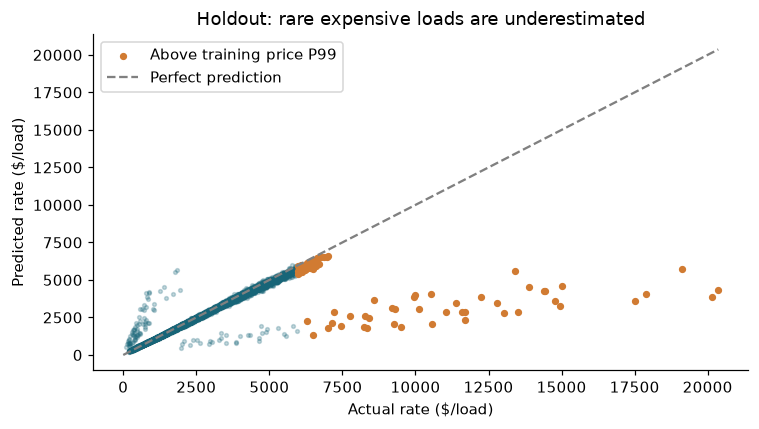

In [7]:
# Determine route familiarity using the training rows only.
training_routes = set(zip(holdout_train.pickup, holdout_train.delivery))
holdout_predictions["route_status"] = ["seen" if route in training_routes else "unseen"
    for route in zip(holdout.pickup, holdout.delivery)]
holdout_predictions["distance_band"] = pd.cut(holdout.distance,
    [-np.inf, 250, 500, 1000, 2000, np.inf], right=False,
    labels=["<250", "250–<500", "500–<1000", "1000–<2000", "2000+"])
# Define an expensive load using training prices, not holdout-derived cutoffs.
price_p99 = holdout_train.posted_rate.quantile(.99)
high_price = holdout.posted_rate.gt(price_p99)
# Compare the same subgroups across models, and flag counts below 100.
group_rows = []
for dimension in ["equipment", "distance_band", "route_status"]:
    for group, subset in holdout_predictions.groupby(dimension, observed=True):
        group_rows.append(dict(group=f"{dimension}: {group}", n=len(subset), small=len(subset) < 100,
            **{name: metrics(subset.posted_rate, subset[name])["mae"]
               for name in [selected_validation, selected_december, "Mileage baseline"]}))
for group, mask in [("Negative weight", holdout.weight.lt(0)), ("Above training price P99", high_price)]:
    subset = holdout_predictions.loc[mask]
    group_rows.append(dict(group=group, n=len(subset), small=len(subset) < 100,
        **{name: metrics(subset.posted_rate, subset[name])["mae"]
           for name in [selected_validation, selected_december, "Mileage baseline"]}))
subgroup_table = pd.DataFrame(group_rows).set_index("group")
display(subgroup_table.rename(columns={name: name + " MAE ($)"
    for name in [selected_validation, selected_december, "Mileage baseline"]}))

# Measure how much expensive loads contribute to the overall squared error.
tail = holdout_predictions.loc[high_price]
tail_error = tail[selected_validation] - tail.posted_rate
all_error = holdout_predictions[selected_validation] - holdout.posted_rate
tail_squared_share = (tail_error ** 2).sum() / (all_error ** 2).sum()
print(f"Training price P99: ${price_p99:,.2f}. All {len(tail)} high-price loads were "
      f"underpredicted: {tail_error.lt(0).all()}.")
print(f"Their MAE is ${tail_error.abs().mean():,.2f}, they contribute {tail_squared_share:.1%} "
      "of squared error. No rows were removed.")

# Points below the diagonal indicate underprediction.
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(holdout.posted_rate, holdout_predictions[selected_validation], s=6, alpha=.25, color="#176578")
ax.scatter(tail.posted_rate, tail[selected_validation], s=14, color="#d17b32", label="Above training price P99")
limit = float(holdout.posted_rate.max())
ax.plot([0, limit], [0, limit], "--", color="gray", label="Perfect prediction")
ax.set(xlabel="Actual rate ($/load)", ylabel="Predicted rate ($/load)", title="Holdout: rare expensive loads are underestimated")
ax.legend()
plt.tight_layout()
plt.show()

All 101 loads above training price P99 are underpredicted, their signal-free MAE is
$3,687, compared with $3,561 for mileage. These loads account for about 86% of squared
error. Some are ordinary high-mileage expensive loads, extreme rates per mile remain
unverified. There is no evidence sufficient to discard them as erroneous.

Only 21 holdout rows have unseen routes and 59 have negative weights. These small
samples do not establish reliable generalization. In contrast, 12.175% of the future
validation rows use routes unseen in development. Calendar trees extrapolate poorly,
and one year cannot validate December seasonality. Location provenance, service
details, customer/carrier dependence, and target availability delays are unresolved.

The measured average improvement supports proceeding with the fixed models for
this assessment, with these limitations recorded. The holdout is not used to tune
the model, adjust predictions, or claim route-specific forecasting accuracy.

## 7. Final training on all labeled development data

Now refit the same two models on all 48,000 January–October labeled rows. This uses
the available labels for submission, without changing features or hyperparameters.
The earlier holdout scores still describe only the January–August training runs.

In [8]:
# After evaluation, refit the same configurations on all available labeled rows.
final_models = {}
with threadpool_limits(limits=2):
    for name, coordinates in [(selected_validation, True), (selected_december, False)]:
        final_models[name] = fit_catboost(development, coordinates)
        print(f"Final fit: {name}, {len(development):,} labeled rows, 450 trees.")

Final fit: Signal-free CatBoost, 48,000 labeled rows, 450 trees.


Final fit: December CatBoost, 48,000 labeled rows, 450 trees.


## 8. Generate the two prediction CSVs

Match validation predictions to the company's template by unique load ID, keeping
its order and exact output columns. For December, change only `predicted_rate`.
Check the raw predictions are finite and positive before saving, no adjustment
is made to create a more attractive December chart.

In [9]:
# Apply the same feature preparation used during model training.
validation_rates = final_models[selected_validation].predict(prepare_features(validation, True))
december_rates = final_models[selected_december].predict(prepare_features(december, False))
# Reject missing, nonfinite, or nonpositive predictions before saving.
for rates, expected_rows in [(validation_rates, 12000), (december_rates, 31)]:
    assert len(rates) == expected_rows and np.isfinite(rates).all() and (rates > 0).all()
    assert (rates >= .01).all(), "Investigate a prediction below the fixed floor before saving."

# Join by unique load ID while preserving the company template order.
rates_by_id = pd.DataFrame({"load_id": validation.load_id, "predicted_rate": validation_rates})
validation_output = template[["load_id"]].merge(rates_by_id, on="load_id", how="left", validate="one_to_one", sort=False)
assert list(validation_output.columns) == ["load_id", "predicted_rate"]
assert validation_output.load_id.tolist() == template.load_id.tolist()
assert validation_output.load_id.is_unique and validation_output.predicted_rate.notna().all()
# Fill only the prediction column, leaving all supplied December inputs unchanged.
december_output = december.copy(deep=True)
december_output["predicted_rate"] = december_rates
assert list(december_output.columns) == ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]
pd.testing.assert_frame_equal(december_output.drop(columns="predicted_rate"), december_inputs)
pd.testing.assert_frame_equal(pd.read_csv(data / "december-chart-inputs.csv").drop(columns="predicted_rate"), december_inputs)

# Save the two CSVs in the exact formats expected by the company scorer.
validation_output.to_csv(ROOT / "validation_predictions.csv", index=False)
december_output.to_csv(ROOT / "december_predictions.csv", index=False)
for filename, output in [("validation_predictions.csv", validation_output), ("december_predictions.csv", december_output)]:
    print(f"{filename}: {len(output):,} rows, rates ${output.predicted_rate.min():,.2f}–${output.predicted_rate.max():,.2f}.")

validation_predictions.csv: 12,000 rows, rates $193.93–$6,718.98.
december_predictions.csv: 31 rows, rates $811.23–$835.10.


## 9. Run the original scorer and view the December chart

The unchanged scorer validates both file formats, expected IDs, dates, fixed inputs,
and positive predictions. It creates the chart below. It does not measure validation
accuracy: the company holds those labels. Only date changes for this fixed scenario,
the resulting weekly pattern is a model estimate, not verified December pricing.

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: C:\Users\mosta\freight-rate-prediction\candidate_december.png
Final validation metrics are calculated by Spotter after submission.



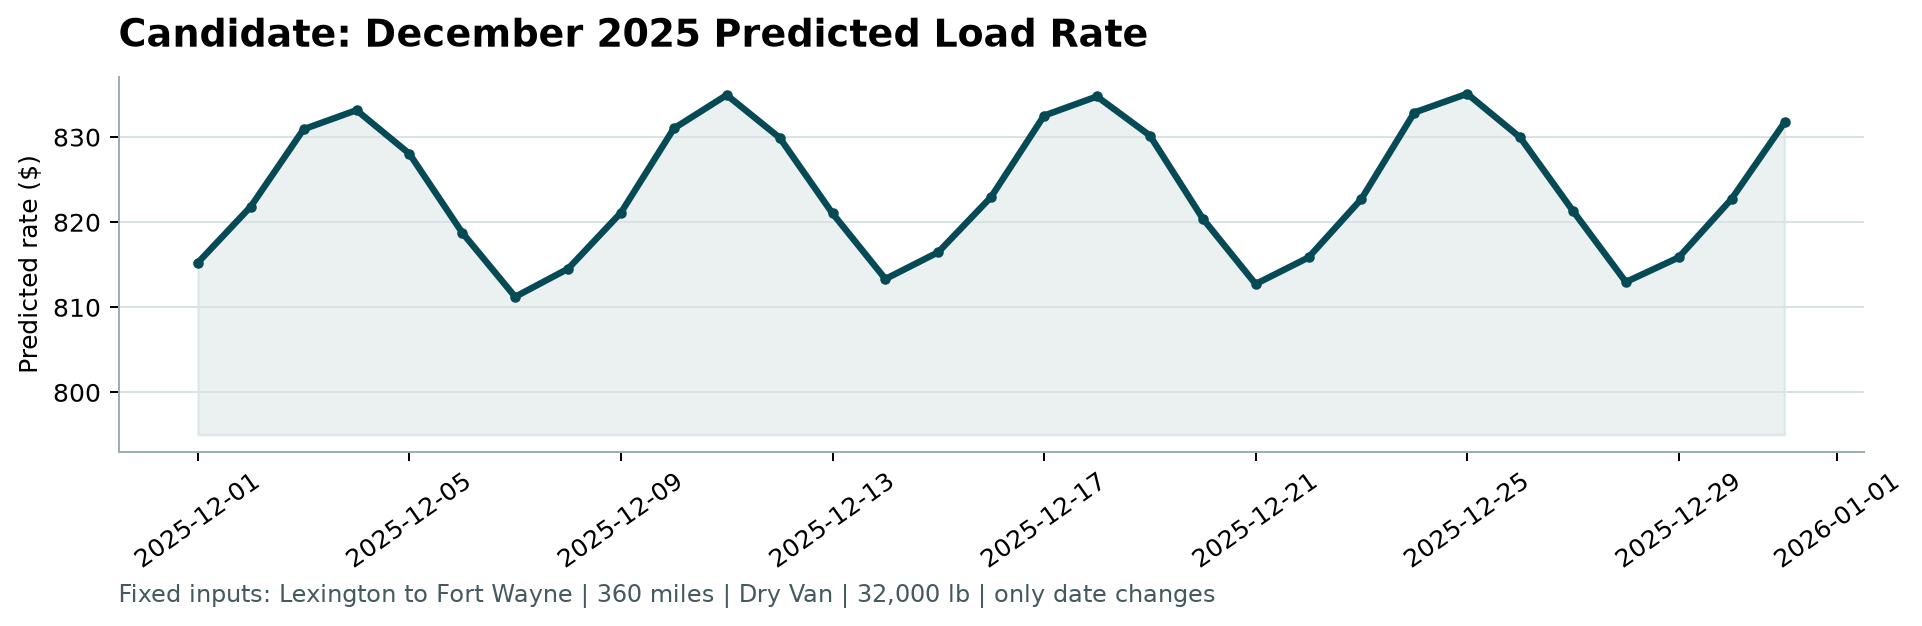

In [10]:
# Run the unchanged scorer with this notebook environment and stop if validation fails.
result = subprocess.run([
    sys.executable, str(ROOT / "score.py"),
    "--predictions", str(ROOT / "validation_predictions.csv"),
    "--december-predictions", str(ROOT / "december_predictions.csv"),
    "--output-dir", str(ROOT),
], cwd=ROOT, capture_output=True, text=True, check=True)
print(result.stdout)
# Display the exact chart created by the scorer.
display(Image(filename=str(ROOT / "candidate_december.png")))

## 10. Create the short assessment report

Write three readable pages using the metrics measured above and the exact scorer
chart. The report summarizes the split, model rationale, results, and limitations.
The README and Loom speaking notes provide the accompanying run instructions and
walkthrough. No models are serialized, and nothing is published or submitted.

In [ ]:
# Assemble a three-page report using measured results and the scorer chart.
report = pymupdf.open()
ink = (.12, .18, .22)
teal = (.04, .29, .34)

# Check that each paragraph fits inside its page area.
def report_text(page, rectangle, text, size=11, color=ink):
    remaining = page.insert_textbox(pymupdf.Rect(*rectangle), text, fontsize=size,
                                    fontname="helv", color=color, lineheight=1.35)
    assert remaining >= 0, "Report text overflow, shorten the paragraph."

overall = holdout_metrics.loc[holdout_metrics.period.eq("ALL")].set_index("model")
# Page 1 explains the data, chronological splits, and model choices.
page = report.new_page(width=595, height=842)
report_text(page, (44, 38, 552, 88), "Freight rate prediction", 24, teal)
report_text(page, (44, 91, 552, 122), "Assessment | approach and model selection", 13, teal)
report_text(page, (44, 145, 552, 223),
    "Objective: predict posted freight rates in dollars per load. The company supplied "
    "48,000 labeled January-October 2025 loads, 12,000 unlabeled November-December "
    "validation loads, and 31 fixed December scenarios. All original input rows are retained.")
report_text(page, (44, 244, 552, 278), "Chronological evaluation", 15, teal)
report_text(page, (44, 282, 552, 393),
    "January-June (28,806 rows) predicts July (4,912), January-July (33,718) predicts "
    "August (4,759). Model choices were fixed using these comparisons and the bounded "
    "error review. January-August (38,477) then predicts September-October (9,523). "
    "There is no holdout tuning or early stopping. Earlier descriptive exploration saw "
    "all development labels, the holdout was unused for selection, rather than analyst-unseen.")
report_text(page, (44, 411, 552, 446), "Why CatBoost, and which features?", 15, teal)
report_text(page, (44, 449, 552, 610),
    "July-August pooled MAE: mileage $250.94, Ridge $212.27, signal-free CatBoost "
    "$122.39, December CatBoost $127.37. CatBoost captures nonlinear physical and "
    "categorical effects. Both selected models use pickup, delivery, distance, "
    "equipment, weight and date, validation also uses four coordinates. Directed "
    "route, weekday/year cycles, elapsed days and an invalid-weight flag are derived. "
    "IDs, target, market_index and quote_signal are excluded. Signal definitions and "
    "prediction-time availability are unconfirmed. Learned preprocessing uses training rows only.")
report_text(page, (44, 623, 552, 757),
    "Fixed settings: 450 CatBoost trees, depth 6, learning rate 0.08, MAE loss, "
    "L2 regularization 5, seed 2025, CPU/two threads, remaining settings are explicit "
    "in the notebook. Negative weights become missing with an indicator. Earlier "
    "masking gains were only $0.38/$0.84 MAE, so the rationale is physical validity, "
    "not a proven large accuracy improvement. The historical Ridge benchmark "
    "retains negative weights for a like-for-like comparison.")
report_text(page, (44, 793, 552, 819), "1 / 3", 9)

# Page 2 summarizes holdout performance and the important limitations.
page = report.new_page(width=595, height=842)
report_text(page, (44, 38, 552, 90), "Measured results and limitations", 22, teal)
report_text(page, (44, 108, 552, 142), "September-October holdout: 9,523 identical rows", 14, teal)
page.insert_text((44, 163), "Model", fontsize=11, color=ink)
for x, label in [(299, "MAE ($)"), (388, "RMSE ($)"), (480, "R-squared")]:
    page.insert_text((x, 163), label, fontsize=11, color=ink)
for y, name in zip([190, 216, 242], [selected_validation, selected_december, "Mileage baseline"]):
    row = overall.loc[name]
    page.insert_text((44, y), name, fontsize=11, color=ink)
    for x, value in [(299, f"{row.mae:.2f}"), (388, f"{row.rmse:.2f}"), (480, f"{row.r2:.5f}")]:
        page.insert_text((x, y), value, fontsize=11, color=ink)
report_text(page, (44, 265, 552, 353),
    "September has 4,670 loads, October has 4,853. Signal-free monthly MAE is "
    "$109.58 / $130.11, December-feature MAE is $120.33 / $152.36, mileage MAE "
    "$260.83 / $253.22. Signal-free overall signed bias is -$81.84. October's "
    "higher errors and broader underprediction are concerns, not reasons to recalibrate against the holdout.")
report_text(page, (44, 370, 552, 405), "Rare expensive loads remain difficult", 15, teal)
report_text(page, (44, 410, 552, 539),
    f"The training price P99 is ${price_p99:,.2f}. All {len(tail)} holdout loads above "
    f"that threshold are underpredicted. Their signal-free MAE is ${tail_error.abs().mean():,.0f}, "
    f"versus ${metrics(tail.posted_rate, tail['Mileage baseline'])['mae']:,.0f} for mileage, "
    f"they contribute {tail_squared_share:.1%} of squared error. The July-August review "
    "also found extreme rate-per-mile misses on known routes with ordinary weights. "
    "MAE loss favors typical prices. No implementation defect or confirmed bad label "
    "was found, no rows were dropped.")
report_text(page, (44, 557, 552, 591), "Practical limits", 15, teal)
report_text(page, (44, 596, 552, 753),
    "Only 21 holdout rows have unseen routes and 59 have negative weights, small "
    "subgroups cannot establish dependable generalization. Future validation has "
    "12.175% development-unseen routes. One year of data and calendar trees offer "
    "limited extrapolation. Geographic provenance, special services, customer/carrier "
    "dependence and label delays are unresolved. Reduced-feature holdout accuracy "
    "does not validate December seasonality or the fixed route. Average improvement "
    "supports using the fixed models for this assessment, with these caveats.")
report_text(page, (44, 793, 552, 819), "2 / 3", 9)

# Page 3 includes the scorer chart and the submission deliverables.
page = report.new_page(width=595, height=842)
report_text(page, (44, 38, 552, 90), "December scenario and deliverables", 22, teal)
report_text(page, (44, 108, 552, 145), "Exact chart from the supplied, unchanged scorer", 14, teal)
page.insert_image(pymupdf.Rect(34, 156, 561, 436), filename=str(ROOT / "candidate_december.png"), keep_proportion=True)
report_text(page, (44, 457, 552, 558),
    f"Lexington to Fort Wayne, 360 miles, Dry Van, 32,000 lb. Only date changes. "
    f"December predictions range from ${december_rates.min():.2f} to ${december_rates.max():.2f}. "
    "There are only 21 development loads on this route with this equipment, and no "
    "exact fixed-input match. The weekly pattern is a model estimate, neither "
    "December nor this route's accuracy has been directly validated.")
report_text(page, (44, 576, 552, 610), "Final training and execution", 15, teal)
report_text(page, (44, 615, 552, 757),
    "After holdout evaluation, both unchanged configurations were refitted on all "
    "48,000 labeled rows. validation_predictions.csv contains 12,000 unique IDs in "
    "template order, december_predictions.csv contains all 31 dates with unchanged "
    "physical inputs. All predictions are finite and positive. The scorer accepts "
    "both files and creates candidate_december.png, it does not report hidden-label "
    "accuracy. Install requirements.txt and run freight_rate_prediction.ipynb from "
    "top to bottom. README.md and loom_script.md accompany this report. Nothing is submitted automatically.")
report_text(page, (44, 793, 552, 819), "3 / 3", 9)
# Write the finished PDF, without publishing or submitting anything.
report.save(ROOT / "assessment_report.pdf", deflate=True)
report.close()
print("Created assessment_report.pdf (3 pages). Workflow complete.")